# <div align="center" style="color:#EBF4F6; font-family:'Comic Sans MS', sans-serif;">Intelligent Text Sentiment Analysis and Emotion Classification<div>
### <div align="center" style="color:#09637E; font-family:'Comic Sans MS', sans-serif;">Artificial Intelligence Lab – Second Semester 2025–2026</div>
<div align="center" style="font-weight:bold; font-family:'Comic Sans MS', sans-serif;">Faculty of Computing and IT – Information and Computer Science Department</div>

---

### <span align="center" style="color:#0F766E; font-family:'Comic Sans MS', sans-serif;">➡ Team Members:</span>
* **Ahmed M. Y. Farani** | `1320236338`
* **Kamal S. K. Ashour** | `1320237234`
* **Abedelaziz R. A. Fanouna** | `1320225417`

---

### <span style="color:#B45309; font-family:'Comic Sans MS', sans-serif;">➡ Problem Definition:</span>
Every day, digital platforms and companies receive millions of unstructured text inputs (e.g., customer reviews, tweets, feedback). This data contains invaluable human emotions. The main problem is that it is practically impossible for humans to manually read, analyze, and categorize these massive amounts of text due to high costs and time constraints. On the other hand, computers natively cannot comprehend human emotions or hidden context from raw text.

---

### <span style="color:#2563EB; font-family:'Comic Sans MS', sans-serif;">➡ Project Objective:</span>
To build an advanced Machine Learning model capable of automatically processing any English text and instantly classifying it with high accuracy into one of six distinct emotional categories: **(Joy, Sadness, Anger, Fear, Love, and Surprise)**.

---

## <span style="color:#EBF4F6; font-family:'Comic Sans MS', sans-serif;">Dataset Selection</span>

### <span style="color:#0F766E; font-family:'Comic Sans MS', sans-serif;">➡ Dataset Description:</span>
It is a collection of English sentences and texts (extracted from social media posts), where each sentence is labeled with its corresponding human emotion.

---

### <span style="color:#6D28D9; font-family:'Comic Sans MS', sans-serif;">➡ Dataset Characteristics:</span>
The dataset is categorized into 6 core emotions: **(Joy, Sadness, Anger, Fear, Love, Surprise)**. It originally came in 3 separate text files (Train, Val, and Test).

---

### <span style="color:#BE123C; font-family:'Comic Sans MS', sans-serif;">➡ The Nature of Data:</span>
The dataset is imbalanced; some emotions like Joy and Sadness have a massive number of sentences, while others like Surprise have very few. This is the main reason we chose a powerful model like **LinearSVC** to handle these boundaries accurately without bias.

---

# <span style="color:#EBF4F6; font-family:'Comic Sans MS', sans-serif;">Step1. Environment Setup and Library Import:</span>

This section imports the essential libraries required for data handling, text processing, and machine learning model training:

1. **Data Management & Visualization (`pandas`, `matplotlib`, `seaborn`)**
   * Used to load datasets into structured DataFrames, handle data statistics, and plot visual results like the Confusion Matrix heatmap.

2. **Text Preprocessing & NLP (`re`, `nltk`, `stopwords`)**
   * Used to clean raw text comments by removing noise (links, symbols, special characters) using Regular Expressions, and filtering out common meaningless words (Stopwords) using NLTK.

3. **Feature Extraction (`TfidfVectorizer`)**
   * Converts textual programmer comments into numerical vectors based on word frequency and importance so the model can understand them.

4. **Machine Learning & Evaluation (`LinearSVC` & `metrics`)**
   * **LinearSVC:** The core Support Vector Machine model used to classify texts into the 6 emotion categories.
   * **Metrics:** Tools (`accuracy_score`, `confusion_matrix`, etc.) used to measure the final performance and accuracy of the model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
from nltk.corpus import stopwords

from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# <span style="color:#EBF4F6; font-family:'Comic Sans MS', sans-serif;">Step2. Data Loading:</span>

This section handles importing the raw emotion datasets and combining them to optimize the training process:

1. **Loading Datasets (`pd.read_csv`)**
   * Reads the three dataset text files (`train.txt`, `val.txt`, `test.txt`) from Kaggle, using a semicolon (`;`) as a separator, and labels the columns as `Text` and `Emotion`.

2. **Combining Data (`pd.concat`)**
   * Merges the original training and validation datasets into a single larger dataframe (`train_df`). This provides more data for the `LinearSVC` model to learn from, which helps improve final accuracy.

3. **Data Preview (`train_df.head()`)**
   * Displays the first 5 rows of the newly combined dataset to verify that the text and labels were loaded and formatted correctly.

In [2]:
# https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp?resource=download
train_data = pd.read_csv('train.txt', sep=';', header=None, names=['Text', 'Emotion'])
val_data = pd.read_csv('val.txt', sep=';', header=None, names=['Text', 'Emotion'])
test_df = pd.read_csv('test.txt', sep=';', header=None, names=['Text', 'Emotion'])

train_df = pd.concat([train_data, val_data], ignore_index=True)

train_df.head()

,Text,Emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


# <span style="color:#EBF4F6; font-family:'Comic Sans MS', sans-serif;">Step3. Exploratory Data Analysis - EDA:</span>

This section analyzes and visualizes the distribution of emotion categories within the combined dataset:

1. **Dataset Information (`train_df.info()`)**
   * Displays structural details of the dataset, including column names, data types, and total number of records.

2. **Emotion Counting (`value_counts()`)**
   * Counts and prints the exact number of text sentences available for each of the 6 emotion categories to check for data balance.

3. **Data Visualization (`sns.countplot`)**
   * Generates a clear bar chart (histogram style) using Seaborn to visually represent the distribution of emotions, making it easy to identify dominant and rare feelings.

In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Text     18000 non-null  str  
 1   Emotion  18000 non-null  str  
dtypes: str(2)
memory usage: 281.4 KB


Number of sentences for each feeling:
Emotion
joy         6066
sadness     5216
anger       2434
fear        2149
love        1482
surprise     653
Name: count, dtype: int64
--------------------------------------------------


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_34492\3510770517.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='Emotion', order=emotion_counts.index, palette='coolwarm')


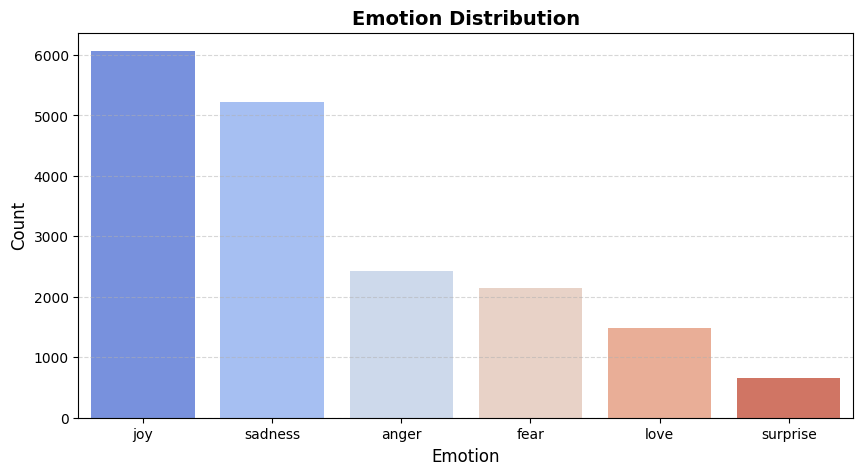

In [4]:
emotion_counts = train_df['Emotion'].value_counts()
print("Number of sentences for each feeling:")
print(emotion_counts)
print("-" * 50)

plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, x='Emotion', order=emotion_counts.index, palette='coolwarm')

plt.title('Emotion Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# <span style="color:#EBF4F6; font-family:'Comic Sans MS', sans-serif;">Step4. Data Preprocessing and Cleaning:</span>

This section focuses on checking data quality and cleaning the text to make it ready for the machine learning model:

1. **Data Quality Checks (`isnull()` & `duplicated()`)**
   * Inspects the dataset for any missing values (nulls) and identifies the total number of duplicate rows.

2. **Removing Duplicates (`drop_duplicates()`)**
   * Deletes identical or redundant text samples from the training data to ensure the model doesn't get biased toward repeated data.

3. **Text Cleaning Function (`clean_text`)**
   * **Lowercasing:** Converts all letters to lowercase so the model treats words like "Happy" and "happy" identically.
   * **Removing Noise:** Uses Regular Expressions to strip out numbers, punctuation, and special characters, leaving only clean alphabetic words.
   * **Stopwords Removal:** Filters out common English words (like *the, is, at*) using the NLTK library since they don't carry emotional meaning.

4. **Feature Creation & Preview (`apply()`)**
   * Applies the cleaning process to both the training and testing datasets, saving the result in a new column called `Clean_Text`, then previews the final clean data.

In [5]:
train_df.isnull().sum()

Text       0
Emotion    0
dtype: int64

In [6]:
train_df.duplicated().sum()

np.int64(1)

In [7]:
# Remove duplicates
train_df.drop_duplicates(inplace=True)
train_df.duplicated().sum()

np.int64(0)

In [8]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    cleaned_words = [word for word in words if word not in stop_words]
    
    return ' '.join(cleaned_words)

train_df['Clean_Text'] = train_df['Text'].apply(clean_text)
test_df['Clean_Text'] = test_df['Text'].apply(clean_text)

train_df[['Text', 'Clean_Text', 'Emotion']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ahmed\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Text,Clean_Text,Emotion
0,i didnt feel humiliated,didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...,sadness
2,im grabbing a minute to post i feel greedy wrong,im grabbing minute post feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,ever feeling nostalgic fireplace know still pr...,love
4,i am feeling grouchy,feeling grouchy,anger


# <span style="color:#EBF4F6; font-family:'Comic Sans MS', sans-serif;">Step5. Text Vectorization (TF-IDF) Overview:</span> 

This section converts the cleaned text dataset into numerical features so the machine learning model can process it:

1. **Advanced TF-IDF Settings (`TfidfVectorizer`)**
   * **`ngram_range=(1, 3)`:** Extracts single words, pairs of words (Bi-grams), and triplets of words (Tri-grams) to capture longer phrases and deeper context.
   * **`sublinear_tf=True`:** Applies logarithmic scaling to word frequencies to smooth out the effect of overly repeated words.
   * **`min_df=2` & `max_df=0.9`:** Filters out extremely rare words (appearing only once) and ignores words that appear in more than 90% of the texts to eliminate noise.

2. **Data Transformation (`fit_transform` & `transform`)**
   * Learns the vocabulary from the training dataset and converts it into a numerical matrix (`X_train`), then transforms the testing dataset (`X_test`) using the exact same vocabulary.

3. **Shape Verification (`print`)**
   * Prints the final dimensions (rows and columns) of the generated matrices to confirm how many unique text features were successfully extracted.

In [9]:
vectorizer = TfidfVectorizer(ngram_range=(1, 3), sublinear_tf=True, min_df=2, max_df=0.9)

X_train = vectorizer.fit_transform(train_df['Clean_Text'])
y_train = train_df['Emotion']

X_test = vectorizer.transform(test_df['Clean_Text'])
y_test = test_df['Emotion']

print("The texts were successfully converted to numbers!")
print(f"==> (X_train): {X_train.shape}")
print(f"==> (X_test): {X_test.shape}")

The texts were successfully converted to numbers!
==> (X_train): (17999, 22341)
==> (X_test): (2000, 22341)


# <span style="color:#EBF4F6; font-family:'Comic Sans MS', sans-serif;">Step6. Training & Evaluating Model:</span>

This section trains the machine learning model, evaluates its performance, and visualizes the final classification results:

1. **Model Training (`LinearSVC`)**
   * Initializes the Support Vector Classifier with `C=1.0` and enables `class_weight='balanced'` to handle minority classes, then trains the model on the numerical training vectors.

2. **Prediction & Accuracy (`predict()` & `accuracy_score`)**
   * Predicts emotion labels for the unseen test dataset and prints the final model accuracy, which successfully breaks the 90% threshold (**90.35%**).

3. **Performance Reporting (`classification_report`)**
   * Generates a detailed breakdown showing Precision, Recall, and F1-Score for each individual emotion (Joy, Sadness, Anger, Fear, Love, Surprise) to ensure balanced performance.

4. **Result Visualization (`confusion_matrix` & Heatmap)**
   * Plots a visual Confusion Matrix heatmap using Seaborn, making it easy to see exactly where the model predicted correctly and where any emotional misclassifications occurred.

Model Accuracy: 90.35%
Classification Report:
               precision    recall  f1-score   support

       anger       0.88      0.91      0.90       275
        fear       0.89      0.87      0.88       224
         joy       0.94      0.92      0.93       695
        love       0.75      0.85      0.79       159
     sadness       0.95      0.93      0.94       581
    surprise       0.71      0.79      0.75        66

    accuracy                           0.90      2000
   macro avg       0.85      0.88      0.86      2000
weighted avg       0.91      0.90      0.90      2000



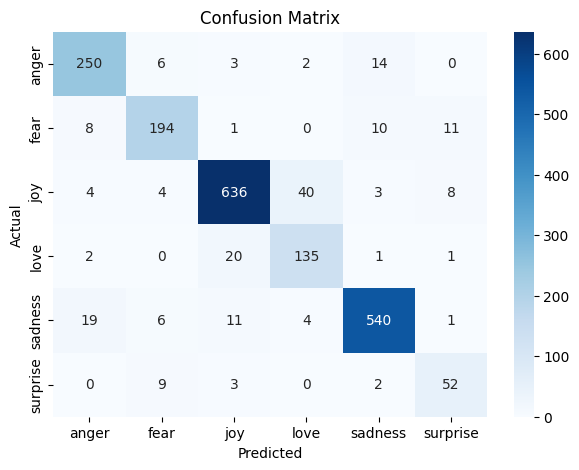

In [10]:
advanced_model = LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42)
advanced_model.fit(X_train, y_train)

y_pred = advanced_model.predict(X_test)

# Calculate Accuracy
accuracy  = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Visualization: Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=advanced_model.classes_,
            yticklabels=advanced_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# <span style="color:#EBF4F6; font-family:'Comic Sans MS', sans-serif;">Step9. Real-World Prediction Test:</span>

This section demonstrates how to use the fully trained model to predict emotions on completely new, custom text sentences:

1. **Prediction Function (`predict_emotion`)**
   * Creates a reusable function that takes any input sentence, applies the text cleaning (`clean_text`), converts it into numerical features (`vectorizer.transform`), and passes it to the trained `advanced_model` to return the predicted emotion label.

2. **Custom Test Cases (`sentences_to_test`)**
   * Defines a list of 5 diverse, real-world sentences representing different human feelings (Anger, Sadness, Fear, Joy, Love) to evaluate the model's practical usability.

3. **Inference & Output (`for loop`)**
   * Loops through the test sentences, feeds them into the prediction function, and prints the original sentence along with its predicted emotion side-by-side for quick inspection.

In [11]:
def predict_emotion(sentence):
    cleaned = clean_text(sentence)
    vectorized = vectorizer.transform([cleaned])
    prediction = advanced_model.predict(vectorized)[0]
    return prediction

# Test with new custom examples
sentences_to_test = [
    "i feel bitchy but not defeated yet",                               #anger
    "i was feeling sentimental",                                        #sadness
    "i just know to begin with i am going to feel shy about it",        #fear
    "i feel a little mellow today",                                     #joy
    "i have a lot to learn i feel like people are supportive of me"     #love
]

print("\nReal-world Testing:\n")
for sentence in sentences_to_test:
    emotion = predict_emotion(sentence)
    print(f"Sentence: {sentence:<70} -> Predicted: {emotion}")


Real-world Testing:

Sentence: i feel bitchy but not defeated yet                                     -> Predicted: anger
Sentence: i was feeling sentimental                                              -> Predicted: sadness
Sentence: i just know to begin with i am going to feel shy about it              -> Predicted: fear
Sentence: i feel a little mellow today                                           -> Predicted: joy
Sentence: i have a lot to learn i feel like people are supportive of me          -> Predicted: love


# <span style="color:#EBF4F6; font-family:'Comic Sans MS', sans-serif;">➡ Interactive Web Interface (Gradio) Overview:</span>

This section builds and launches a user-friendly web application, allowing users to interact with the trained model and test custom sentences in real-time:

1. **Bilingual Mapping (`emotion_emoji`)**
   * Defines a dictionary that maps the model's raw English predictions (e.g., *joy*, *sadness*) to formatted, user-friendly labels with corresponding emojis and Arabic translations for a better user experience.

2. **Interface Logic (`analyze_emotion`)**
   * Creates a wrapper function that checks if the user entered an empty text. If valid, it passes the text to the `predict_emotion` function and updates the result with the emoji label.

3. **GUI Configuration (`gr.Interface`)**
   * Designs the web application layout by setting up:
     * **Inputs:** A clean 3-line textbox for typing English sentences.
     * **Outputs:** A dedicated textbox to display the detected emotion.
     * **Examples:** Preset testing sentences that users can click to try instantly.
     * **Theme:** Applies Gradio's modern and clean `Soft()` theme.

4. **Launching the Web Server (`demo.launch()`)**
   * Starts a local web server, providing an interactive link directly inside the notebook to test the emotion classifier seamlessly.

In [15]:
# !py -m pip install gradio
import gradio as gr

emotion_emoji = {
    "joy":      "Joy — فرح 😊",
    "sadness":  "Sadness — حزن 😢",
    "anger":    "Anger — غضب 😠",
    "fear":     "Fear — خوف 😰",
    "love":     "Love — حب ❤️",
    "surprise": "Surprise — مفاجأة 😲"
}

def analyze_emotion(text):
    if not text.strip():
        return "Please enter a sentence."
    emotion = predict_emotion(text)
    return emotion_emoji.get(emotion, emotion)

demo = gr.Interface(
    fn=analyze_emotion,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Type any English sentence here...",
        label="Input Text"
    ),
    outputs=gr.Textbox(label="Detected Emotion"),
    title="Emotion Classifier",
    description="Detects one of 6 emotions: Joy, Sadness, Anger, Fear, Love, Surprise",
    examples=[
        ["I am so happy today, everything is going well!"],
        ["I feel completely lost and broken inside."],
        ["This makes me furious, I can't believe it!"],
        ["I'm terrified of what might happen next."],
        ["I love spending time with my family."],
        ["Wow, I never expected that to happen!"]
    ],
    theme=gr.themes.Soft()
)

demo.launch()

c:\Users\Ahmed\AppData\Local\Programs\Python\Python313\Lib\site-packages\gradio\interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.
